# 🔬 Semiconductor Production Test Data Analysis Pipeline
**Author:** Sanusi Isiaka Olatunji | M.Sc. Data Science | University of Leoben  
**Aligned with:** Infineon Technologies Data Science Internship  

**Pipeline:**
1. Synthetic IC production dataset generation
2. Preprocessing — median imputation, Winsorisation, StandardScaler
3. Anomaly Detection — Isolation Forest + Z-Score hybrid
4. Visualisation — distributions, heatmap, PCA map, sensitivity chart

In [1]:
# ── Install (Colab already has these, but ensures latest versions) ──────────
!pip install -q scikit-learn scipy matplotlib pandas numpy

In [2]:
# ── Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print('✅ Imports OK')

✅ Imports OK


In [3]:
# ── 1. SYNTHETIC DATASET ────────────────────────────────────────────────────
N_SAMPLES, N_ANOMALIES = 1_200, 60

nominal = {
    'VDD_mV':       (1800, 30),   # supply voltage [mV]
    'IDD_uA':       (250,  20),   # quiescent current [µA]
    'TEMP_C':       (27,    8),   # die temperature [°C]
    'FREQ_MHz':     (100,   5),   # oscillator frequency [MHz]
    'LEAKAGE_nA':   (15,    4),   # gate leakage [nA]
    'VOUT_mV':      (3300, 50),   # LDO output [mV]
    'RISE_TIME_ns': (2.5, 0.3),   # signal rise time [ns]
}
FEATURES = list(nominal.keys())

df = pd.DataFrame({c: np.random.normal(m, s, N_SAMPLES) for c,(m,s) in nominal.items()})

# Inject anomalies (~5% defect rate)
ai = np.random.choice(N_SAMPLES, N_ANOMALIES, replace=False)
df.loc[ai, 'VDD_mV']       = df.loc[ai, 'VDD_mV']       + np.random.choice([-200, 220], N_ANOMALIES)
df.loc[ai, 'IDD_uA']       = df.loc[ai, 'IDD_uA']       * np.random.uniform(2.5, 4.0, N_ANOMALIES)
df.loc[ai, 'LEAKAGE_nA']   = df.loc[ai, 'LEAKAGE_nA']   * np.random.uniform(5.0, 10.0, N_ANOMALIES)
df.loc[ai, 'RISE_TIME_ns'] = df.loc[ai, 'RISE_TIME_ns'] + np.random.uniform(3, 8, N_ANOMALIES)

# Simulate 3% missing values (sensor drop-outs)
miss_mask = np.random.rand(*df.shape) < 0.03
df_raw = df.copy()
for r, c in zip(*np.where(miss_mask)):
    df_raw.iloc[r, c] = np.nan

df_raw.index = [f'CHI-{i:05d}' for i in range(N_SAMPLES)]
df_raw.index.name = 'chip_id'

print(f'Dataset shape : {df_raw.shape}')
print(f'Missing values: {df_raw.isna().sum().sum()} ({df_raw.isna().mean().mean()*100:.1f}%)')
df_raw.describe().round(2)

Dataset shape : (1200, 7)
Missing values: 222 (2.6%)


,VDD_mV,IDD_uA,TEMP_C,FREQ_MHz,LEAKAGE_nA,VOUT_mV,RISE_TIME_ns
count,1163.00,1170.00,1170.00,1170.00,1170.00,1171.00,1164.00
mean,1804.09,278.12,27.17,99.66,19.93,3298.37,2.77
std,55.54,124.61,8.21,4.94,24.00,51.25,1.23
min,1548.25,189.61,3.07,84.12,3.40,3138.95,1.35
25%,1780.72,237.89,21.43,96.39,12.37,3262.50,2.31
50%,1802.09,251.35,27.22,99.83,15.10,3297.74,2.52
75%,1822.07,265.88,32.56,102.93,17.99,3334.71,2.76
max,2067.84,1038.69,58.41,116.22,207.45,3476.45,10.99


In [4]:
# ── 2. PREPROCESSING ────────────────────────────────────────────────────────
df_clean = df_raw[FEATURES].copy()

# Median imputation (robust to outliers)
for col in FEATURES:
    med = df_clean[col].median()
    n_m = int(df_clean[col].isna().sum())
    df_clean[col] = df_clean[col].fillna(med)
    if n_m:
        print(f'  Imputed {n_m:>3d} missing in {col:<18s} (median = {med:.2f})')

# Winsorise at 1st / 99th percentile
for col in FEATURES:
    lo, hi = df_clean[col].quantile([0.01, 0.99])
    df_clean[col] = df_clean[col].clip(lo, hi)

# Standardise
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_clean.values)
assert not np.isnan(X_scaled).any(), 'NaN found after preprocessing!'

print('\n✅ Preprocessing complete')
print('   Steps: Median Imputation → Winsorisation [1%–99%] → StandardScaler')

  Imputed  37 missing in VDD_mV             (median = 1802.09)
  Imputed  30 missing in IDD_uA             (median = 251.35)
  Imputed  30 missing in TEMP_C             (median = 27.22)
  Imputed  30 missing in FREQ_MHz           (median = 99.83)
  Imputed  30 missing in LEAKAGE_nA         (median = 15.10)
  Imputed  29 missing in VOUT_mV            (median = 3297.74)
  Imputed  36 missing in RISE_TIME_ns       (median = 2.52)

✅ Preprocessing complete
   Steps: Median Imputation → Winsorisation [1%–99%] → StandardScaler


In [5]:
# ── 3. ANOMALY DETECTION ────────────────────────────────────────────────────

# Method A: Isolation Forest
iso      = IsolationForest(contamination=0.05, random_state=SEED, n_estimators=200)
iso_lbl  = iso.fit_predict(X_scaled)          # -1 = anomaly
iso_scr  = iso.decision_function(X_scaled)    # lower = more anomalous

# Method B: Z-Score (univariate, per feature)
z_scores = np.abs(stats.zscore(X_scaled, axis=0))
z_flag   = (z_scores > 3.0).any(axis=1)

# Combined: flag if EITHER method triggers
combined = (iso_lbl == -1) | z_flag

df_clean['anomaly']       = combined
df_clean['anomaly_score'] = -iso_scr   # higher = more suspicious

n_iso = int((iso_lbl == -1).sum())
n_z   = int(z_flag.sum())
n_all = int(combined.sum())

print(f'Isolation Forest flagged : {n_iso}')
print(f'Z-Score (|z| > 3) flagged: {n_z}')
print(f'Combined (union) flagged : {n_all}  ({n_all/N_SAMPLES*100:.1f}%)')

# Preview top suspicious chips
df_clean[df_clean['anomaly']].sort_values('anomaly_score', ascending=False).head(8)

Isolation Forest flagged : 60
Z-Score (|z| > 3) flagged: 60
Combined (union) flagged : 60  (5.0%)


,VDD_mV,IDD_uA,TEMP_C,FREQ_MHz,LEAKAGE_nA,VOUT_mV,RISE_TIME_ns,anomaly,anomaly_score
chip_id,,,,,,,,,
CHI-00844,2024.993566,702.076957,25.617586,90.316236,152.664669,3418.281669,9.114296,True,0.173775
CHI-00122,1642.083829,908.598386,29.939853,91.809855,152.664669,3261.908766,9.104086,True,0.168592
CHI-00766,1603.440210,877.938058,23.880610,97.371845,152.664669,3406.779337,9.114296,True,0.166287
CHI-00071,2025.596447,780.642044,45.254974,104.361577,152.664669,3224.572202,9.114296,True,0.163914
CHI-00584,1605.455988,643.004618,13.760901,97.606207,152.664669,3379.708898,9.114296,True,0.158673
CHI-00392,1980.393004,746.823526,23.696017,90.122561,152.664669,3220.492908,9.113720,True,0.157827
CHI-00741,1603.440210,625.319069,9.982181,100.959489,152.664669,3280.345490,5.886042,True,0.150517
CHI-01121,2025.596447,854.980710,9.005612,102.589974,152.630347,3257.927524,7.908079,True,0.149321


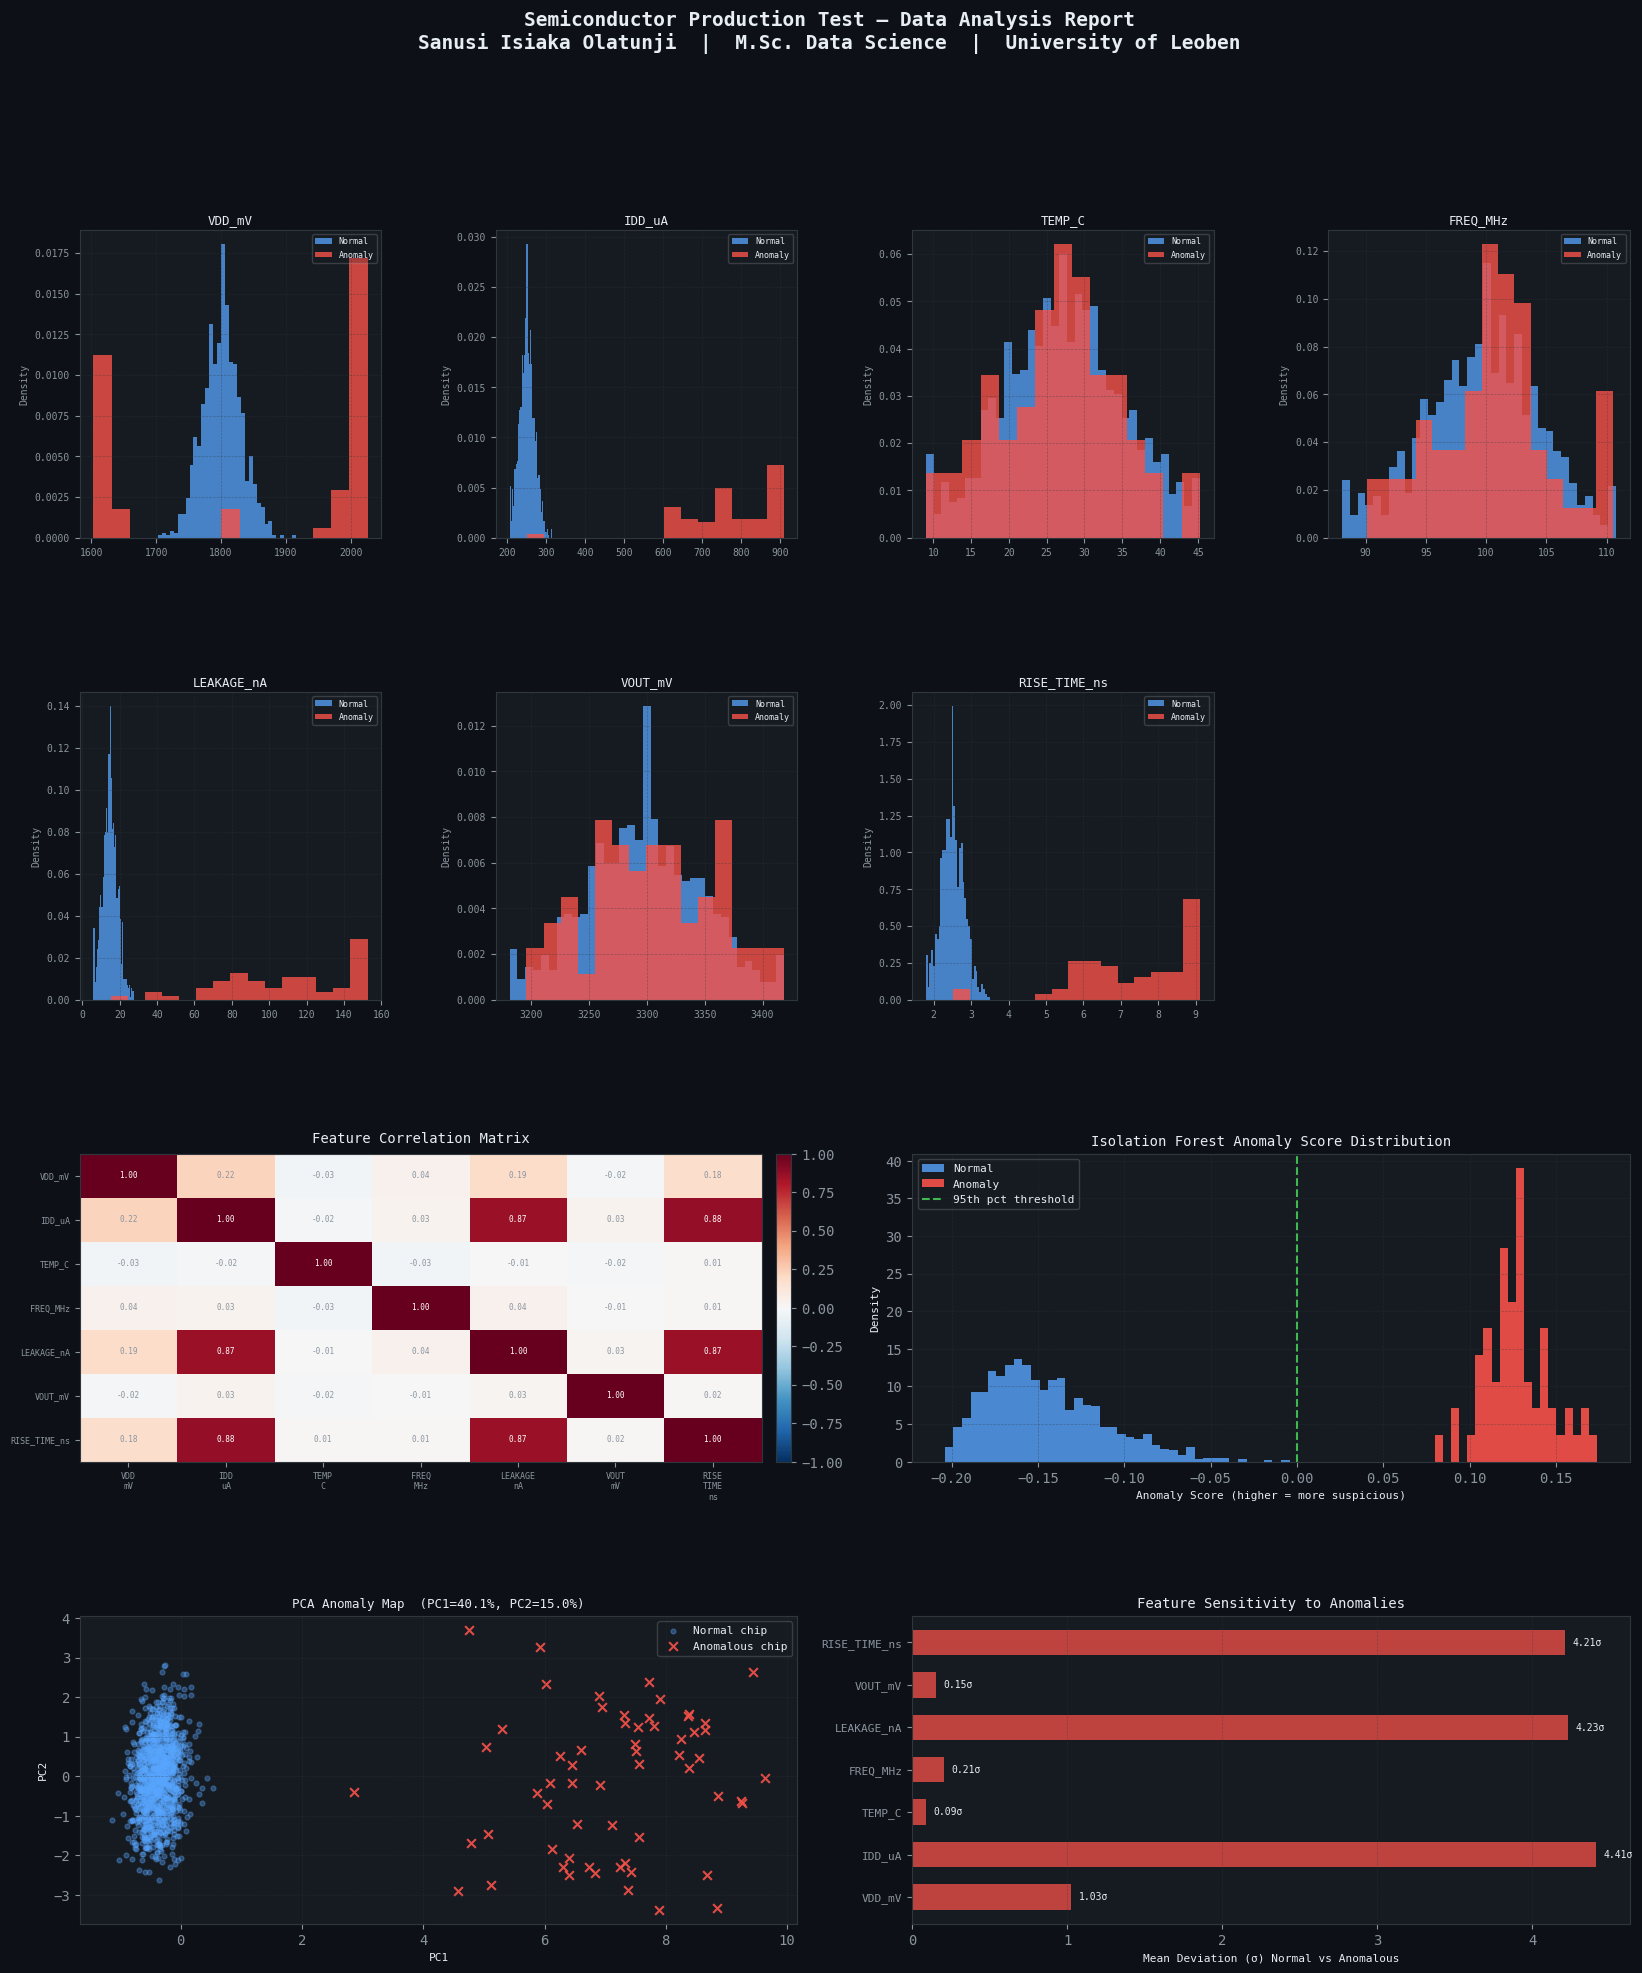

✅ Report saved as semiconductor_analysis_report.png


In [6]:
# ── 4. VISUALISATION ────────────────────────────────────────────────────────
CB='#0d1117'; CP='#161b22'; CBR='#30363d'
CT='#e6edf3'; CM='#8b949e'; CN='#58a6ff'; CA='#f85149'; CG='#3fb950'

plt.rcParams.update({
    'figure.facecolor':CB,'axes.facecolor':CP,'axes.edgecolor':CBR,
    'axes.labelcolor':CT,'xtick.color':CM,'ytick.color':CM,
    'text.color':CT,'grid.color':CBR,'grid.linestyle':'--',
    'grid.linewidth':0.5,'font.family':'monospace'
})

fig = plt.figure(figsize=(20, 22), facecolor=CB)
fig.suptitle(
    'Semiconductor Production Test — Data Analysis Report\n'
    'Sanusi Isiaka Olatunji  |  M.Sc. Data Science  |  University of Leoben',
    fontsize=14, color=CT, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.50, wspace=0.38)

nm = ~df_clean['anomaly']
am =  df_clean['anomaly']

# (A) Feature distributions
for i, col in enumerate(FEATURES):
    row, c = divmod(i, 4)
    ax = fig.add_subplot(gs[row, c])
    ax.hist(df_clean.loc[nm, col], bins=35, color=CN, alpha=0.75, label='Normal',  density=True)
    ax.hist(df_clean.loc[am, col], bins=15, color=CA, alpha=0.80, label='Anomaly', density=True)
    ax.set_title(col, fontsize=9, color=CT, pad=4)
    ax.set_ylabel('Density', fontsize=7, color=CM)
    ax.tick_params(labelsize=7); ax.grid(True, alpha=0.4)
    ax.legend(fontsize=6, framealpha=0.2, labelcolor=CT, loc='upper right')

# (B) Correlation heatmap
ax_h = fig.add_subplot(gs[2, :2])
corr = df_clean[FEATURES].corr()
im   = ax_h.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax_h.set_xticks(range(len(FEATURES))); ax_h.set_yticks(range(len(FEATURES)))
ax_h.set_xticklabels([f.replace('_','\n') for f in FEATURES], fontsize=6)
ax_h.set_yticklabels(FEATURES, fontsize=6)
ax_h.set_title('Feature Correlation Matrix', fontsize=10, color=CT, pad=8)
for r in range(len(FEATURES)):
    for c in range(len(FEATURES)):
        ax_h.text(c, r, f"{corr.values[r,c]:.2f}", ha='center', va='center',
                  fontsize=5.5, color='white' if abs(corr.values[r,c])>0.5 else CM)
plt.colorbar(im, ax=ax_h, fraction=0.03, pad=0.02)

# (C) Anomaly score distribution
ax_s = fig.add_subplot(gs[2, 2:])
ax_s.hist(df_clean.loc[nm, 'anomaly_score'], bins=40, color=CN, alpha=0.8, label='Normal',  density=True)
ax_s.hist(df_clean.loc[am, 'anomaly_score'], bins=20, color=CA, alpha=0.9, label='Anomaly', density=True)
ax_s.axvline(df_clean['anomaly_score'].quantile(0.95), color=CG, lw=1.5, ls='--', label='95th pct threshold')
ax_s.set_title('Isolation Forest Anomaly Score Distribution', fontsize=10, color=CT)
ax_s.set_xlabel('Anomaly Score (higher = more suspicious)', fontsize=8)
ax_s.set_ylabel('Density', fontsize=8)
ax_s.legend(fontsize=8, framealpha=0.2, labelcolor=CT); ax_s.grid(True, alpha=0.4)

# (D) PCA 2D anomaly map
ax_p = fig.add_subplot(gs[3, :2])
pca  = PCA(n_components=2, random_state=SEED)
Xp   = pca.fit_transform(X_scaled)
ax_p.scatter(Xp[nm, 0], Xp[nm, 1], c=CN, alpha=0.35, s=12, label='Normal chip')
ax_p.scatter(Xp[am, 0], Xp[am, 1], c=CA, alpha=0.90, s=40, marker='x', linewidths=1.5, label='Anomalous chip')
ax_p.set_title(
    f'PCA Anomaly Map  (PC1={pca.explained_variance_ratio_[0]*100:.1f}%,'
    f' PC2={pca.explained_variance_ratio_[1]*100:.1f}%)',
    fontsize=9, color=CT)
ax_p.set_xlabel('PC1', fontsize=8); ax_p.set_ylabel('PC2', fontsize=8)
ax_p.legend(fontsize=8, framealpha=0.2, labelcolor=CT); ax_p.grid(True, alpha=0.4)

# (E) Feature sensitivity
ax_b = fig.add_subplot(gs[3, 2:])
sens = [abs(df_clean.loc[am, c].mean() - df_clean.loc[nm, c].mean()) /
        (df_clean[c].std() + 1e-9) for c in FEATURES]
bars = ax_b.barh(FEATURES, sens, color=CA, alpha=0.75, height=0.6)
ax_b.set_xlabel('Mean Deviation (σ) Normal vs Anomalous', fontsize=8)
ax_b.set_title('Feature Sensitivity to Anomalies', fontsize=10, color=CT)
ax_b.tick_params(axis='y', labelsize=8); ax_b.grid(True, axis='x', alpha=0.4)
for bar, val in zip(bars, sens):
    ax_b.text(val+0.05, bar.get_y()+bar.get_height()/2,
              f'{val:.2f}σ', va='center', fontsize=7, color=CT)

plt.savefig('semiconductor_analysis_report.png', dpi=150, bbox_inches='tight', facecolor=CB)
plt.show()
print('✅ Report saved as semiconductor_analysis_report.png')

In [7]:
# ── 5. SUMMARY ──────────────────────────────────────────────────────────────
top_feat = FEATURES[int(np.argmax(sens))]
print('='*60)
print('  ANALYSIS SUMMARY')
print('='*60)
print(f'  Chips tested            : {N_SAMPLES:,}')
print(f'  Features analysed       : {len(FEATURES)}')
print(f'  Missing values imputed  : {int(miss_mask.sum()):,}')
print(f'  Anomalies detected      : {n_all}  ({n_all/N_SAMPLES*100:.1f}%)')
print(f'    Isolation Forest      : {n_iso}')
print(f'    Z-Score (|z|>3)       : {n_z}')
print(f'  Most sensitive feature  : {top_feat}')
print(f'  PCA variance (2 PCs)    : {pca.explained_variance_ratio_[:2].sum()*100:.1f}%')
print('='*60)

# Download the PNG
from google.colab import files
files.download('semiconductor_analysis_report.png')

  ANALYSIS SUMMARY
  Chips tested            : 1,200
  Features analysed       : 7
  Missing values imputed  : 222
  Anomalies detected      : 60  (5.0%)
    Isolation Forest      : 60
    Z-Score (|z|>3)       : 60
  Most sensitive feature  : IDD_uA
  PCA variance (2 PCs)    : 55.1%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>